<a href="https://colab.research.google.com/github/vedant08mehta/shopper_spectrum/blob/main/shopping_spectrum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project Name - Shopper spectrum by Vedant Mehta

Project Type - EDA & ML Model

Contribution - Individual



Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Uploading csv file

In [2]:
from google.colab import files
uploaded = files.upload()

Saving online_retail.csv to online_retail.csv


In [3]:
data = pd.read_csv("online_retail.csv")

Dataset Information

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
data.shape

(541909, 8)

Checking Null Values

In [7]:
data.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


Cleaning the Data

In [8]:
data = data[~data['InvoiceNo'].astype(str).str.startswith('C')]

In [9]:
data = data.dropna(subset=["Description", "CustomerID"])

In [10]:
data.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [21]:
data = data[data['Quantity'] > 0]

In [22]:
data = data[data['UnitPrice'] > 0]

In [23]:
data["TotalPrice"] = data["UnitPrice"] * data["Quantity"]

In [24]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

In [25]:
data['CustomerID'] = data['CustomerID'].astype(str)

In [29]:
data.reset_index(drop=True, inplace=True)

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397884 entries, 0 to 397883
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  object        
 7   Country      397884 non-null  object        
 8   TotalPrice   397884 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 27.3+ MB


Missing values from the columns Description and CustomerID have been removed

InoviceNo starting with c have been removed because they are cancelled

Zero and negative quantities have been removed from the columns Quantity and UnitPrice

A new column named TotalPrice has been made which is the Quanity of items times the UnitPrice

The column InvoiceDate has been changed to date time format

CustomerID has been converted to string type

Data Visualization (Graphs)

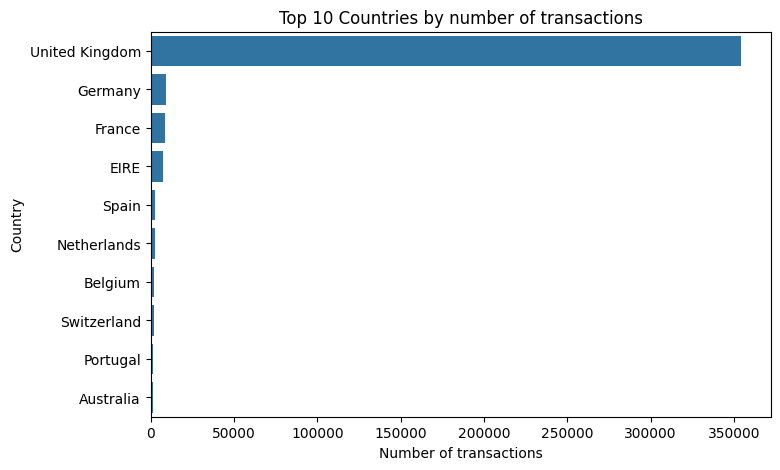

In [32]:
top_countries = data["Country"].value_counts().head(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries by number of transactions")
plt.xlabel("Number of transactions")
plt.ylabel("Country")
plt.show()

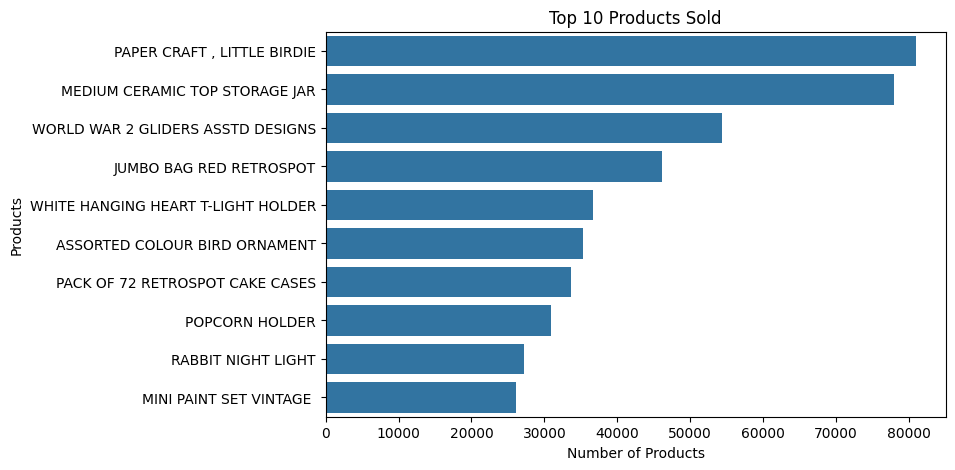

In [33]:
top_products = data.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Products Sold")
plt.xlabel("Number of Products")
plt.ylabel("Products")
plt.show()

INSIGHTS

The data is mostly from UK.

The most sold products are mostly gifting items and decorating items.

So there should be an increase in the inventory of these items, which would help business.

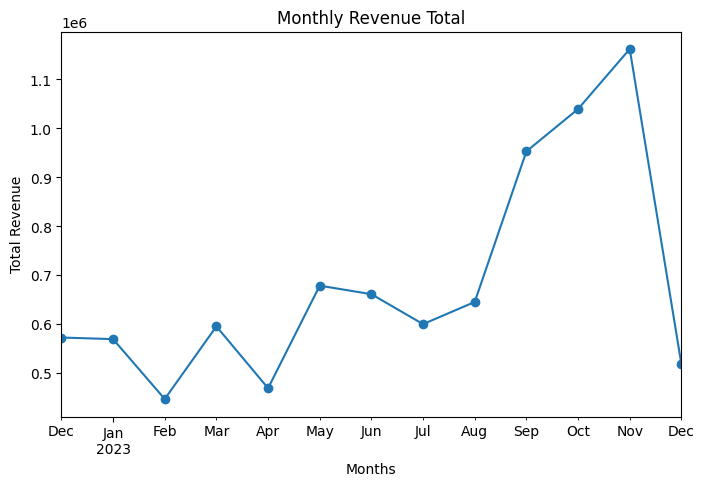

In [49]:
data['InvoiceMonth'] = data['InvoiceDate'].dt.to_period('M')
monthly_revenue = data.groupby('InvoiceMonth')['TotalPrice'].sum()
plt.figure(figsize=(8, 5))
monthly_revenue.plot(kind='line', marker='o')
plt.title("Monthly Revenue Total")
plt.xlabel("Months")
plt.ylabel("Total Revenue")
plt.show()

INSIGHTS

This chart shows how the revenue fluctuates over the months.

There is a clear and big spike in the months of November and December, which are the gifting months.

A clear dip in the months of February and April since there are no holidays during that time.

The low revenue months can be improved by having promotions and flash sales to drive customers and increase revenue.

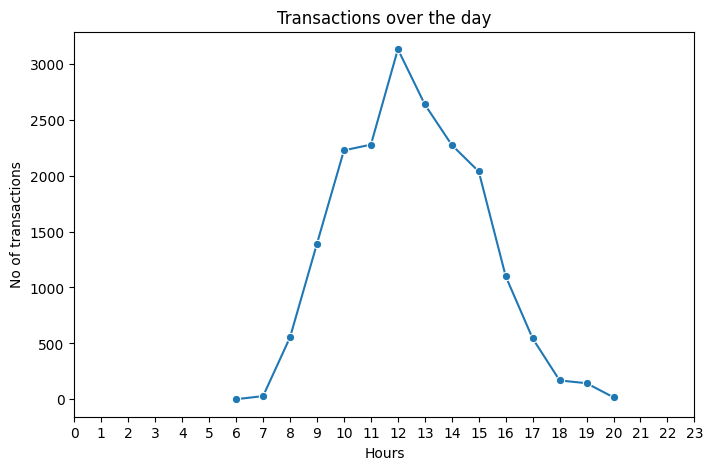

In [50]:
data['InvoiceHour'] = data['InvoiceDate'].dt.hour
hourly_transactions = data.groupby('InvoiceHour')['InvoiceNo'].nunique()
plt.figure(figsize=(8, 5))
sns.lineplot(x=hourly_transactions.index, y=hourly_transactions.values, marker='o')
plt.title("Transactions over the day")
plt.xlabel("Hours")
plt.ylabel("No of transactions")
plt.xticks(range(0, 24))
plt.show()

INSIGHTS

This chart tells us the busiest hours of the day.

11am to 1pm record the highest transactions in the day.

There is a dip in activity from 3pm onwards.

There is good activity during 11am to 3pm.

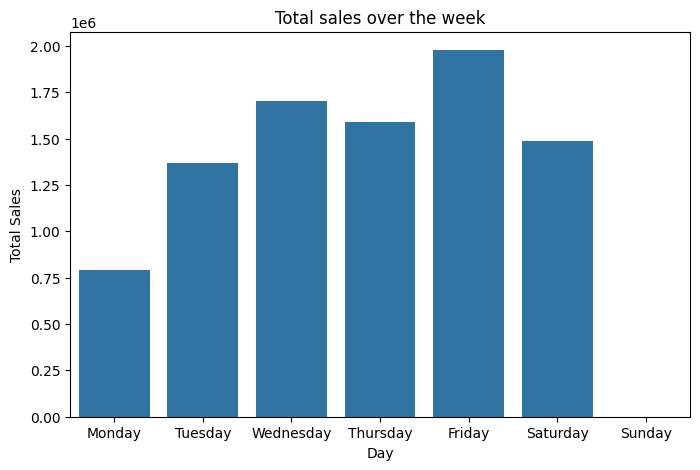

In [53]:
data['Weekday'] = data['InvoiceDate'].dt.day_name()
weekday_transactions = data.groupby('Weekday')['TotalPrice'].sum().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.figure(figsize=(8, 5))
sns.barplot(x=weekday_transactions.index, y=weekday_transactions.values)
plt.xlabel("Day")
plt.ylabel('Total Sales')
plt.title('Total sales over the week')
plt.show()

INSIGHTS


Friday has recorded the most sales and activity.


Sunday shows no sale so people prefer relaxing and spending their time with their families.


Monday shows very less sales which makes sense since it is the first working day of the week.


On Sundays, there can be promotions or fun activities that can be arranged in the store that would get people to come with their families and participate. This would significantly help with the sales.

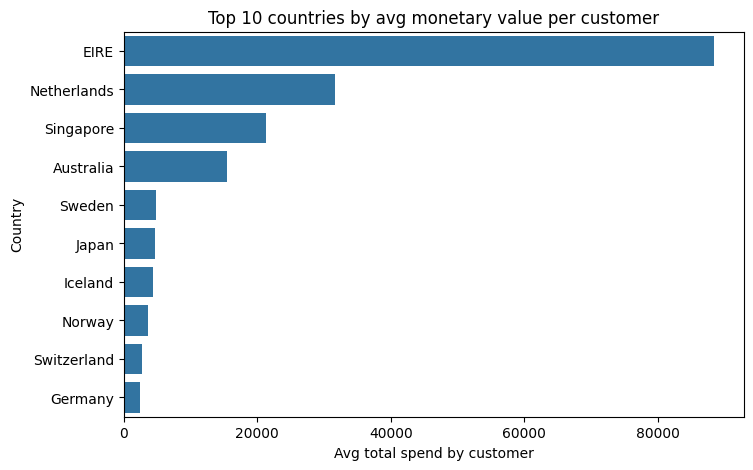

In [54]:
country_wise = data.groupby(["Country", "CustomerID"])["TotalPrice"].sum().reset_index()
avg_country_wise = country_wise.groupby("Country")["TotalPrice"].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=avg_country_wise.values, y=avg_country_wise.index)
plt.title("Top 10 countries by avg monetary value per customer")
plt.xlabel("Avg total spend by customer")
plt.ylabel("Country")
plt.show()

In [57]:
selected = data[["InvoiceNo", "CustomerID", "InvoiceDate", "TotalPrice"]]

In [59]:
snapshot_date = selected['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm_df = selected.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm_df.columns = ['Recency', 'Frequency', 'Monetary']

In [60]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
scaled_data = scaler.fit_transform(rfm_df[['Recency', 'Frequency', 'Monetary']])

In [62]:
inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

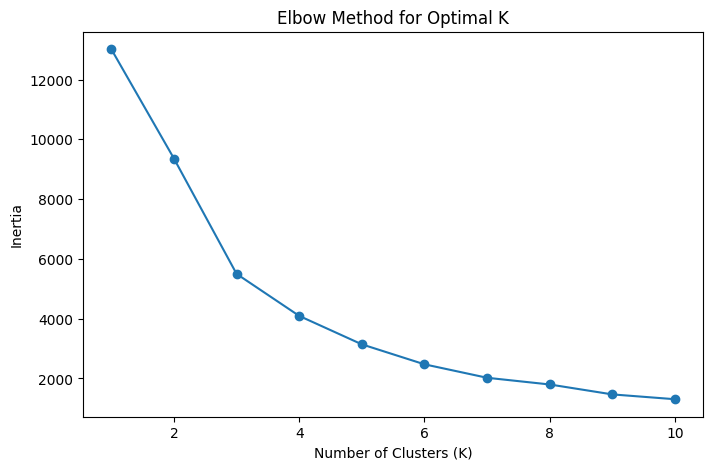

In [63]:
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

In [65]:
from sklearn.metrics import silhouette_score

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    print(f"K={k}, Silhouette Score={score:.3f}")

K=2, Silhouette Score=0.560
K=3, Silhouette Score=0.585
K=4, Silhouette Score=0.616
K=5, Silhouette Score=0.617
K=6, Silhouette Score=0.598


In [61]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm_df['Cluster'] = kmeans.fit_predict(scaled_data)

In [66]:
cluster_profile = rfm_df.groupby('Cluster').mean()
cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


In [68]:
cluster_labels = {
    0: 'High-Value',
    1: 'Regular',
    2: 'Occasional',
    3: 'At-Risk'
}
rfm_df['Segment'] = rfm_df['Cluster'].map(cluster_labels)

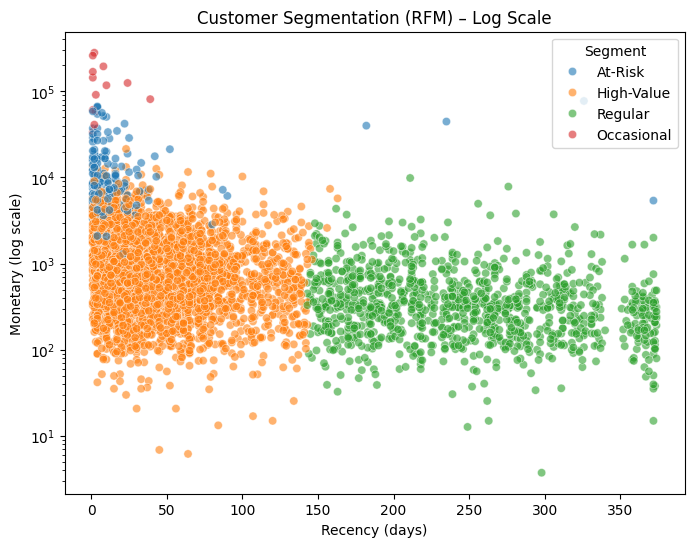

In [70]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=rfm_df['Recency'],
    y=rfm_df['Monetary'],
    hue=rfm_df['Segment'],
    alpha=0.6
)

plt.yscale('log')   # 🔥 KEY FIX
plt.title("Customer Segmentation (RFM) – Log Scale")
plt.xlabel("Recency (days)")
plt.ylabel("Monetary (log scale)")
plt.show()

In [74]:
rfm_df.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,At-Risk
12347.0,2,7,4310.00,0,High-Value
12348.0,75,4,1797.24,0,High-Value
12349.0,19,1,1757.55,0,High-Value
12350.0,310,1,334.40,1,Regular


In [75]:
customer_segments = rfm_df.reset_index()[[
    'CustomerID', 'Recency', 'Frequency', 'Monetary', 'Segment'
]]

customer_segments.to_csv("customer_segments.csv", index=False)

In [77]:
basket = data.pivot_table(
    index='CustomerID',
    columns='Description',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

In [78]:
basket_binary = basket.applymap(lambda x: 1 if x > 0 else 0)

/tmp/ipython-input-2015292794.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_binary = basket.applymap(lambda x: 1 if x > 0 else 0)


In [79]:
from sklearn.metrics.pairwise import cosine_similarity

product_similarity = cosine_similarity(basket_binary.T)

In [80]:
product_similarity_df = pd.DataFrame(
    product_similarity,
    index=basket_binary.columns,
    columns=basket_binary.columns
)

In [81]:
recommendations = {}

for product in product_similarity_df.columns:
    top5 = (
        product_similarity_df[product]
        .sort_values(ascending=False)
        .iloc[1:6]
        .index
        .tolist()
    )
    recommendations[product] = top5

rec_df = pd.DataFrame.from_dict(recommendations, orient='index').reset_index()
rec_df.columns = ['Product', 'Rec1', 'Rec2', 'Rec3', 'Rec4', 'Rec5']

rec_df.to_csv("product_recommendations.csv", index=False)

In [82]:
from google.colab import files
files.download("product_recommendations.csv")
files.download("customer_segments.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>